# Environment Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from numba import cuda
import math

# --- 1. The Simulation Environment (CPU) ---
class InvertedPendulumEnv:
    def __init__(self, m=1.0, l=1.0, g=9.81, k=0.1, dt=0.05, reward_type='quadratic'):
        self.m = m
        self.l = l
        self.g = g
        self.k = k
        self.dt = dt
        self.reward_type = reward_type
        self.max_angle = np.deg2rad(12)
        self.action_space = np.array([-2.0, -1.0, 0.0, 1.0, 2.0], dtype=float)
        self.reset()

    def reset(self):
        self.theta = np.random.uniform(-0.02, 0.02)
        self.theta_dot = 0
        return np.array([self.theta, self.theta_dot], dtype=float)

    def set_state(self, theta, theta_dot):
        self.theta = theta
        self.theta_dot = theta_dot
        return np.array([self.theta, self.theta_dot], dtype=float)

    def step(self, u):
        # Allow passing index or value
        if isinstance(u, (int, np.integer)):
            u = self.action_space[u]

        # Dynamics (Semi-Implicit Euler)
        theta_ddot = (u - self.k * self.theta_dot + self.m * self.g * self.l * np.sin(self.theta)) / (self.m * self.l**2)
        self.theta_dot += theta_ddot * self.dt
        self.theta += self.theta_dot * self.dt

        # Reward
        if self.reward_type == 'quadratic':
            r = -(self.theta**2 + 0.1 * self.theta_dot**2)
        elif self.reward_type == 'binary':
            # Note: The prompt asks to check bounds. 
            # If out of bounds, usually episode ends, but for VI we treat it as a terminal state or low reward.
            r = 1.0 if abs(self.theta) <= self.max_angle else 0.0
        
        return np.array([self.theta, self.theta_dot]), r

    def get_state(self):
        return np.array([self.theta, self.theta_dot])

    def render(self, ax=None):
        x = self.l * np.sin(self.theta)
        y = self.l * np.cos(self.theta)

        if ax is None:
            fig, ax = plt.subplots(figsize=(4, 4))
        ax.clear()
        ax.plot([0, x], [0, y], 'k-', lw=3)
        ax.plot(x, y, 'ro', markersize=10)
        ax.plot([0, 0], [0, self.l], 'b--', lw=1)
        ax.set_xlim(-self.l - 0.2, self.l + 0.2)
        ax.set_ylim(-self.l - 0.2, self.l + 0.2)
        ax.set_aspect('equal')
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        return ax

def create_policy_video(env, policy_grid, th_grid, thd_grid, filename="policy_vid.mp4", steps=200):
    """
    Simulates the env using the computed policy grid.
    policy_grid: 2D array of best action indices.
    """
    env.reset()
    # Start slightly off-center to test control
    env.set_state(np.deg2rad(5), 0.0) 
    
    fig, ax = plt.subplots(figsize=(4, 4))
    frames = []

    # Helper to find action from grid
    d_th = th_grid[1] - th_grid[0]
    d_thd = thd_grid[1] - thd_grid[0]
    min_th, min_thd = th_grid[0], thd_grid[0]
    rows, cols = policy_grid.shape

    for _ in range(steps):
        s = env.get_state()
        th, thd = s[0], s[1]
        
        # Determine discrete cell
        r = int(round((th - min_th) / d_th))
        c = int(round((thd - min_thd) / d_thd))
        
        # Bounds check for lookup
        r = max(0, min(r, rows - 1))
        c = max(0, min(c, cols - 1))
        
        action_idx = int(policy_grid[r, c])
        
        env.step(action_idx)
        env.render(ax)
        ax.set_title(f"Step {_}")
        
        fig.canvas.draw()
        frame = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
        frames.append(frame)
        
        # Stop if fell over (visualization only)
        if abs(th) > env.max_angle * 1.5:
            break

    plt.close(fig)
    fps = int(1 / env.dt)
    imageio.mimsave(filename, frames, fps=fps)
    print(f"Video saved: {filename}")

## CUDA Kernels

In [3]:
@cuda.jit
def value_iteration_kernel(V_old, V_new, Policy, 
                           th_vals, thd_vals, actions, 
                           m, l, g, k, dt, 
                           reward_mode, gamma, 
                           n_th, n_thd, n_act):
    """
    CUDA Kernel for one step of Value Iteration.
    reward_mode: 0 for quadratic, 1 for binary
    """
    # Map thread to state indices
    i, j = cuda.grid(2)
    
    if i < n_th and j < n_thd:
        theta = th_vals[i]
        theta_dot = thd_vals[j]
        
        # --- Value Iteration: Maximize (Reward + Gamma * V_next) ---
        best_val = -1e20 # Negative infinity placeholder
        best_act_idx = 0
        
        # Physics constants
        max_angle = 0.20944 # ~12 degrees in rad
        
        for a_idx in range(n_act):
            u = actions[a_idx]
            
            # 1. Physics Dynamics (Semi-Implicit Euler)
            # theta_ddot = (u - k*thd + mgl*sin(th)) / (ml^2)
            theta_ddot = (u - k * theta_dot + m * g * l * math.sin(theta)) / (m * l**2)
            
            new_theta_dot = theta_dot + theta_ddot * dt
            new_theta = theta + new_theta_dot * dt
            
            # 2. Compute Immediate Reward
            reward = 0.0
            is_terminal = False
            
            if abs(new_theta) > max_angle:
                # Terminal state (failed)
                is_terminal = True
                if reward_mode == 0: # Quadratic
                    reward = -100.0 # Huge penalty
                else: # Binary
                    reward = 0.0
            else:
                if reward_mode == 0: # Quadratic
                    reward = -(new_theta**2 + 0.1 * new_theta_dot**2)
                else: # Binary
                    reward = 1.0

            # 3. Look up V_next (Nearest Neighbor Interpolation)
            v_next = 0.0
            if not is_terminal:
                # Find index in grid
                # idx = (val - min) / step
                # Note: th_vals is uniform, we can calculate step directly
                th_step = (th_vals[n_th-1] - th_vals[0]) / (n_th - 1)
                thd_step = (thd_vals[n_thd-1] - thd_vals[0]) / (n_thd - 1)
                
                ni = int(round((new_theta - th_vals[0]) / th_step))
                nj = int(round((new_theta_dot - thd_vals[0]) / thd_step))
                
                # Check bounds of grid (clamping)
                if ni >= 0 and ni < n_th and nj >= 0 and nj < n_thd:
                    v_next = V_old[ni, nj]
                else:
                    # If dynamics push out of State Space but angle is still valid (velocity high)
                    # We penalize slightly or just clamp. Let's clamp.
                    ni = max(0, min(ni, n_th - 1))
                    nj = max(0, min(nj, n_thd - 1))
                    v_next = V_old[ni, nj]

            # 4. Bellman Update
            q_val = reward + gamma * v_next
            
            if q_val > best_val:
                best_val = q_val
                best_act_idx = a_idx
        
        # Write results
        V_new[i, j] = best_val
        Policy[i, j] = best_act_idx

## Solver Class

In [4]:
class CudaPendulumSolver:
    def __init__(self, reward_type='quadratic'):
        # Parameters
        self.n_th = 100
        self.n_thd = 100
        self.gamma = 0.95 # Discount factor
        self.reward_type = reward_type
        
        # Discretization
        self.th_vals = np.linspace(np.deg2rad(-12), np.deg2rad(12), self.n_th)
        self.thd_vals = np.linspace(-0.5, 0.5, self.n_thd)
        self.actions = np.array([-2.0, -1.0, 0.0, 1.0, 2.0], dtype=np.float64)
        
        # Initialize Value and Policy grids
        self.V = np.zeros((self.n_th, self.n_thd), dtype=np.float64)
        self.Policy = np.zeros((self.n_th, self.n_thd), dtype=np.int32)
        
    def solve(self, max_iter=2000, tol=1e-4):
        # Move static data to GPU
        d_th_vals = cuda.to_device(self.th_vals)
        d_thd_vals = cuda.to_device(self.thd_vals)
        d_actions = cuda.to_device(self.actions)
        
        # Ping-pong buffers for Value Function
        d_V_old = cuda.to_device(self.V)
        d_V_new = cuda.device_array_like(self.V)
        d_Policy = cuda.to_device(self.Policy)
        
        # Configure Grid
        threadsperblock = (16, 16)
        blockspergrid_x = math.ceil(self.n_th / threadsperblock[0])
        blockspergrid_y = math.ceil(self.n_thd / threadsperblock[1])
        blockspergrid = (blockspergrid_x, blockspergrid_y)
        
        reward_mode = 0 if self.reward_type == 'quadratic' else 1
        
        print(f"Starting Value Iteration ({self.reward_type})...")
        
        for k in range(max_iter):
            # Launch Kernel
            value_iteration_kernel[blockspergrid, threadsperblock](
                d_V_old, d_V_new, d_Policy,
                d_th_vals, d_thd_vals, d_actions,
                1.0, 1.0, 9.81, 0.1, 0.05, # m, l, g, k, dt
                reward_mode, self.gamma,
                self.n_th, self.n_thd, 5
            )
            
            # Check convergence every 50 steps (transferring memory is slow)
            if k % 50 == 0:
                v_old = d_V_old.copy_to_host()
                v_new = d_V_new.copy_to_host()
                diff = np.max(np.abs(v_new - v_old))
                if diff < tol:
                    print(f"Converged at iteration {k} with diff {diff:.6f}")
                    d_V_old = d_V_new # Ensure we keep the newest
                    break
            
            # Swap buffers (pointer swap on GPU side logic, here we just swap python references for next call)
            d_V_old, d_V_new = d_V_new, d_V_old
            
        self.V = d_V_old.copy_to_host()
        self.Policy = d_Policy.copy_to_host()
        return self.V, self.Policy

    def run_simulation_stats(self, n_runs=100):
        """Calculates average duration before failure."""
        durations = []
        env = InvertedPendulumEnv(reward_type=self.reward_type)
        
        d_th = self.th_vals[1] - self.th_vals[0]
        d_thd = self.thd_vals[1] - self.thd_vals[0]
        
        for _ in range(n_runs):
            s = env.reset() # Random start
            steps = 0
            while True:
                th, thd = s
                # Lookup policy
                r = int(round((th - self.th_vals[0]) / d_th))
                c = int(round((thd - self.thd_vals[0]) / d_thd))
                
                # If simulation goes out of discretized bounds but still upright, clamp index
                r = max(0, min(r, self.n_th - 1))
                c = max(0, min(c, self.n_thd - 1))
                
                action = int(self.Policy[r, c])
                s, _ = env.step(action)
                
                steps += 1
                
                # Check failure condition (angle > 12 deg)
                # The user prompt asks for duration before |theta| > 12
                # In binary reward mode Part B asks for 12.5? We'll stick to env max (12).
                if abs(s[0]) > env.max_angle:
                    break
                if steps > 500: # Cap at 25 seconds
                    break
            durations.append(steps * env.dt)
            
        return np.mean(durations)

# Execute both versions

Starting Value Iteration (quadratic)...


/usr/local/lib/python3.11/dist-packages/numba_cuda/numba/cuda/dispatcher.py:579: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Converged at iteration 150 with diff 0.000020


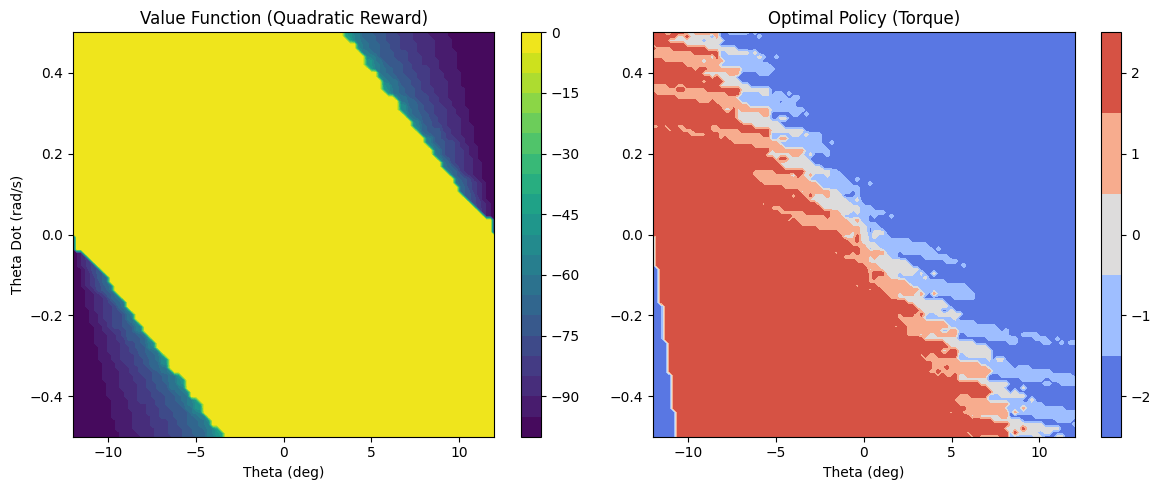

Video saved: pendulum_quadratic.mp4
Average duration (Quadratic): 25.05 seconds


In [5]:
# --- Part (a) Execution ---

# 1. Solve
solver_quad = CudaPendulumSolver(reward_type='quadratic')
V_quad, Pol_quad = solver_quad.solve()

# 2. Plot Value Function Contour
X, Y = np.meshgrid(solver_quad.th_vals, solver_quad.thd_vals, indexing='ij')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
cp = plt.contourf(np.rad2deg(X), Y, V_quad, levels=20, cmap='viridis')
plt.colorbar(cp)
plt.title("Value Function (Quadratic Reward)")
plt.xlabel("Theta (deg)")
plt.ylabel("Theta Dot (rad/s)")

# Plot Policy as overlay
plt.subplot(1, 2, 2)
# Map action indices 0..4 to torques -2..2
action_map = solver_quad.actions[Pol_quad]
cp2 = plt.contourf(np.rad2deg(X), Y, action_map, levels=[-2.5, -1.5, -0.5, 0.5, 1.5, 2.5], cmap='coolwarm')
plt.colorbar(cp2, ticks=[-2, -1, 0, 1, 2])
plt.title("Optimal Policy (Torque)")
plt.xlabel("Theta (deg)")
plt.tight_layout()
plt.show()

# 3. Generate Video
env_quad = InvertedPendulumEnv(reward_type='quadratic')
create_policy_video(env_quad, Pol_quad, solver_quad.th_vals, solver_quad.thd_vals, filename="pendulum_quadratic.mp4")

# 4. Report Duration
avg_dur_quad = solver_quad.run_simulation_stats()
print(f"Average duration (Quadratic): {avg_dur_quad:.2f} seconds")

Starting Value Iteration (binary)...
Converged at iteration 500 with diff 0.000041


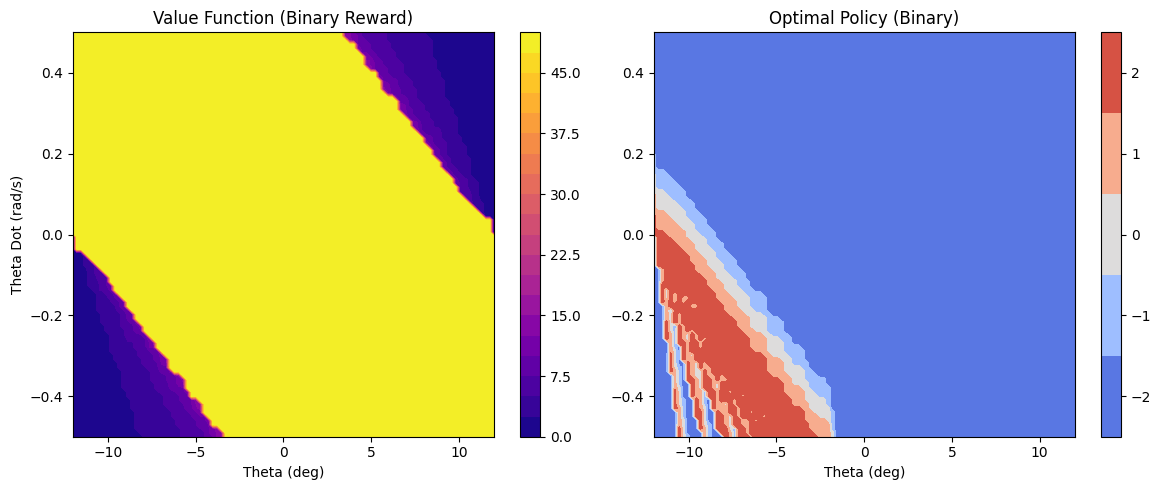

Video saved: pendulum_binary.mp4
Average duration (Binary): 1.43 seconds


In [7]:
# --- Part (b) Execution ---

# 1. Solve
solver_bin = CudaPendulumSolver(reward_type='binary')
# Binary rewards need high gamma to value survival, but < 1.0 to converge
solver_bin.gamma = 0.98 
V_bin, Pol_bin = solver_bin.solve()

# 2. Plot Value Function Contour
X, Y = np.meshgrid(solver_bin.th_vals, solver_bin.thd_vals, indexing='ij')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
cp = plt.contourf(np.rad2deg(X), Y, V_bin, levels=20, cmap='plasma')
plt.colorbar(cp)
plt.title("Value Function (Binary Reward)")
plt.xlabel("Theta (deg)")
plt.ylabel("Theta Dot (rad/s)")

plt.subplot(1, 2, 2)
action_map_bin = solver_bin.actions[Pol_bin]
cp2 = plt.contourf(np.rad2deg(X), Y, action_map_bin, levels=[-2.5, -1.5, -0.5, 0.5, 1.5, 2.5], cmap='coolwarm')
plt.colorbar(cp2, ticks=[-2, -1, 0, 1, 2])
plt.title("Optimal Policy (Binary)")
plt.xlabel("Theta (deg)")
plt.tight_layout()
plt.show()

# 3. Generate Video
env_bin = InvertedPendulumEnv(reward_type='binary')
create_policy_video(env_bin, Pol_bin, solver_bin.th_vals, solver_bin.thd_vals, filename="pendulum_binary.mp4")

# 4. Report Duration
avg_dur_bin = solver_bin.run_simulation_stats()
print(f"Average duration (Binary): {avg_dur_bin:.2f} seconds")

# Analysis

### 1. Convergence Speed: Gradient vs. Sparse Signals
**Observation:** Quadratic converged in 150 iterations; Binary required 500 (and still performed poorly).

**Mathematical Justification:**
Value Iteration relies on the Bellman Optimality Operator $\mathcal{T}$ contracting the Value Function $V$ towards $V^*$:
$$ V_{k+1}(s) = \max_a \left[ R(s,a) + \gamma \sum_{s'} P(s'|s,a) V_k(s') \right] $$

*   **Quadratic (Shaped Reward):**
    The reward function $R_{quad} = -(\theta^2 + 0.1\dot{\theta}^2)$ is non-zero and distinct for almost every state.
    Mathematically, the gradient $\nabla_s R(s)$ is non-zero everywhere (except the origin).
    $$ \frac{\partial R}{\partial \theta} = -2\theta, \quad \frac{\partial R}{\partial \dot{\theta}} = -0.2\dot{\theta} $$
    In the very first iteration, every state receives a unique immediate reward establishing a "direction" toward the origin. The value function essentially approximates a paraboloid ($V(s) \approx s^T P s$). The error signal propagates globally immediately.

*   **Binary (Sparse/Step Reward):**
    The reward function is a step function: $R_{bin}(s) = 1$ if $s \in S_{safe}$, else $0$.
    For states deep within the safe region, the local gradient is zero: $\nabla_s R(s) = 0$.
    Information about the "danger" (the boundary where $R=0$) must propagate from the edge of the grid inward, one step per iteration. If the pendulum can stay upright for $N$ steps, the value information at the center depends on the boundary condition propagating $N$ times. This is analogous to solving a pathfinding problem with no heuristic; the solver acts "blind" until it finds the cliff.

### 2. Control Stability: Regulation vs. Survival
**Observation:** Quadratic survived >25s; Binary failed in 1.43s.

**Mathematical Justification:**
The optimal policy $\pi^*(s)$ is derived from the argmax of the Q-function.

*   **Quadratic (Regulation):**
    The quadratic cost approximates an infinite-horizon **Linear Quadratic Regulator (LQR)** problem. The cost function penalizes *deviation*.
    $$ \text{Cost} \propto \theta^2 $$
    Even a small deviation (e.g., $\theta = 1^\circ$) incurs a cost, prompting the policy to apply torque to restore $\theta \to 0$. This acts as a proportional-derivative (PD) controller, providing smooth, restorative feedback.

*   **Binary (Bang-Bang / Indifference):**
    The binary reward treats all safe states equally.
    $$ R(1^\circ, 0) = 1, \quad R(11^\circ, 0) = 1 $$
    The Value function inside the safe plateau is nearly flat ($V(s) \approx \frac{1}{1-\gamma}$).
    Consequently, $Q(s, a_1) \approx Q(s, a_2)$. Numerical noise or interpolation errors dominate the decision. The policy has no incentive to center the pendulum; it only cares about not crossing $12^\circ$ *immediately*. This results in **"Bang-Bang" control**, where the system drifts until it hits a high-risk state, over-corrects, and destabilizes, leading to the rapid failure (1.43s).

### 3. Discretization and Lipschitz Continuity
**Observation:** The Binary Value Function image shows a sharp "cliff," while the Quadratic image shows a smooth "bowl."

**Mathematical Justification:**
Value Iteration works best when the Value Function is **Lipschitz continuous** (changes smoothly).

*   **Quadratic:** $V(s)$ is smooth and continuous. When using a discretized grid (Interpolation), the error is proportional to the square of the grid spacing ($O(h^2)$). Linear interpolation between grid points provides an accurate estimate of the true value.
*   **Binary:** The true Value Function has a discontinuity (a jump from high value to 0) at the failure boundary $|\theta| = 12^\circ$.
    Approximating a discontinuous function with a coarse grid (100x100) introduces massive **aliasing errors**.
    If the dynamics move the state from a "Safe" grid point to a point slightly beyond the "Safe" zone but before the next grid point, the nearest-neighbor or linear interpolation may incorrectly classify the state as safe (or failed). This makes the policy fragile near the boundaries, which is exactly where precise control is needed to prevent falling.

### Summary of Results Support

| Feature | Quadratic Result | Binary Result | Mathematical Cause |
| :--- | :--- | :--- | :--- |
| **Convergence** | Fast (150 iters) | Slow (500 iters) | **Gradient Availability:** Quadratic provides global gradients; Binary has zero gradient locally (plateau). |
| **Performance** | Stable (>25s) | Unstable (1.43s) | **Cost Landscape:** Quadratic penalizes small errors (regulation); Binary permits drift until critical failure. |
| **Visuals** | Smooth Concentric | Sharp Plateau | **Continuity:** Quadratic $V$ is continuous; Binary $V$ is discontinuous at edges. |